Title: Land_Sea_Mask.ipynb

Purpose: Create a land/sea mask to use for the roughness parameter for the wind scaling of CMIP6 data

Author: Onno Nennecke on 25.06.2025 Modified: 

Output data:

- land_sea_mask
    - This file lies here: /home/onennecke/sea_land_mask/land_sea_mask.nc

Import packages

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import regionmask
import Functions.grid_func as grid_func
import Functions.config as config

/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


Load data

In [2]:
# Create reference grid
ref_grid = grid_func.create_ref_grid('mask')

In [3]:
land_sea_mask = regionmask.defined_regions.natural_earth_v5_0_0.land_110
mask = land_sea_mask.mask(ref_grid)
boolean_mask = mask.notnull()  # Land = True, Sea = False

# Change 0 to offshore and 1 to onshore
final_mask = xr.where(
    boolean_mask,         # where True (land)
    config.a_onshore,     #   → onshore
    config.a_offshore     # where False (sea) → offshore
)

# Save the final mask
final_mask.to_netcdf('/home/onennecke/Capacity_data/alpha_land_sea.nc')

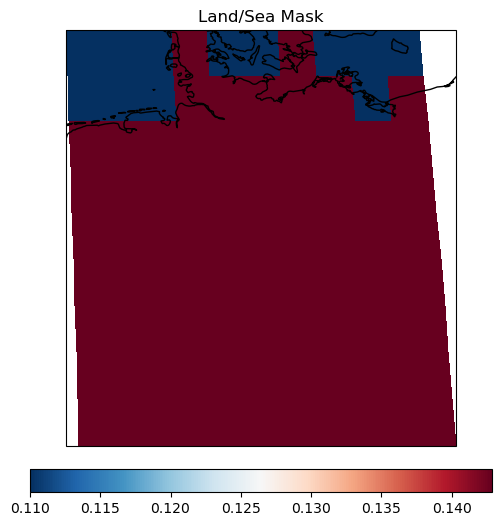

In [4]:
fig, (ax1) = plt.subplots(nrows=1, figsize=(9, 6), subplot_kw={'projection': ccrs.Robinson()})

ax1.coastlines()
xxx = final_mask
im1 = ax1.pcolormesh(xxx.lon, xxx.lat, xxx, transform=ccrs.PlateCarree(), cmap='RdBu_r')
ax1.set_title('Land/Sea Mask')
cbar1 = fig.colorbar(im1, ax=ax1, orientation='horizontal', pad=0.05, fraction=0.05)

plt.show()